Mini Project
TriBagas Nurkholis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('ab_testing_dataset_100k.csv')
df_clean = df.copy() 

DATA PREPARATION

In [12]:
#Melihat informasi data 5 teratas
df_clean.head(20)

,user_id,variant,date,device,browser,country,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,traffic_source,gender,age
0,1,A,2025-01-09,Mobile,Chrome,TH,10,0,0,0,100000,122,1,TikTok Ads,M,20
1,2,B,2025-01-04,Tablet,Edge,ID,6,1,0,0,50000,325,24,Organic,F,21
2,3,A,2025-01-06,Mobile,Firefox,MY,4,0,0,0,200000,446,25,Google Ads,F,38
3,4,A,2025-01-24,Tablet,Safari,TH,2,1,1,0,50000,441,11,Organic,F,42
4,5,A,2025-01-26,Desktop,Edge,ID,5,0,0,0,100000,188,26,TikTok Ads,F,40
5,6,B,2025-01-02,Mobile,Safari,TH,10,0,0,0,250000,557,27,Google Ads,F,45
6,7,A,2025-01-01,Tablet,Edge,MY,12,0,1,0,200000,342,12,Instagram,M,18
7,8,A,2025-01-23,Mobile,Chrome,TH,5,1,0,0,150000,583,7,Instagram,M,19
8,9,A,2025-01-17,Mobile,Safari,ID,8,0,0,0,150000,209,7,Organic,M,25
9,10,B,2025-01-04,Mobile,Safari,MY,5,0,1,0,50000,278,14,TikTok Ads,F,39


In [6]:
#melihat tipe data dan jumlah data yang kosong atau null
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_id           100000 non-null  int64 
 1   variant           100000 non-null  object
 2   date              100000 non-null  object
 3   device            100000 non-null  object
 4   browser           100000 non-null  object
 5   country           100000 non-null  object
 6   page_view         100000 non-null  int64 
 7   click             100000 non-null  int64 
 8   add_to_cart       100000 non-null  int64 
 9   purchase          100000 non-null  int64 
 10  revenue           100000 non-null  int64 
 11  session_duration  100000 non-null  int64 
 12  impressions       100000 non-null  int64 
 13  traffic_source    100000 non-null  object
 14  gender            100000 non-null  object
 15  age               100000 non-null  int64 
dtypes: int64(9), object(7)
memory usage: 12

In [5]:
#Melihat statistik deskriptif dari data
df_clean.describe()

,user_id,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,age
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0000,100000.000000,100000.000000,100000.000000
mean,50000.500000,7.484790,0.299250,0.150640,0.070610,124799.0000,314.640710,14.975070,36.049640
std,28867.657797,4.030701,0.457932,0.357699,0.256174,85376.7093,164.450137,8.356514,10.668443
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.0000,30.000000,1.000000,18.000000
25%,25000.750000,4.000000,0.000000,0.000000,0.000000,50000.0000,172.000000,8.000000,27.000000
50%,50000.500000,7.000000,0.000000,0.000000,0.000000,100000.0000,315.000000,15.000000,36.000000
75%,75000.250000,11.000000,1.000000,0.000000,0.000000,200000.0000,457.000000,22.000000,45.000000
max,100000.000000,14.000000,1.000000,1.000000,1.000000,250000.0000,599.000000,29.000000,54.000000


In [7]:
#Mengecek apakah ada missing value
df_clean.isnull().sum()

user_id             0
variant             0
date                0
device              0
browser             0
country             0
page_view           0
click               0
add_to_cart         0
purchase            0
revenue             0
session_duration    0
impressions         0
traffic_source      0
gender              0
age                 0
dtype: int64

In [8]:
#mengecek apakah ada duplikasi data
df_clean.duplicated().sum()

np.int64(0)

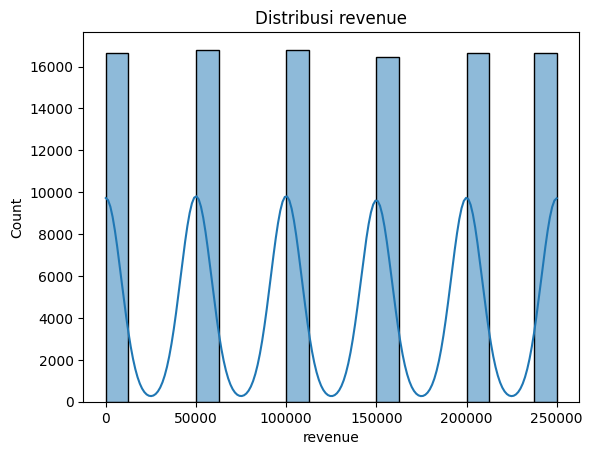

In [9]:
#Mengecek distribusi data revenue
sns.histplot(df_clean['revenue'], bins = 20, kde=True)
plt.title('Distribusi revenue')

mean = df_clean['revenue'].mean()
std = df_clean['revenue'].std()
x = np.linspace(df_clean['revenue'].min(), df_clean['revenue'].max(), 100)
pdf = stats.norm.pdf(x, mean, std)
plt.show()

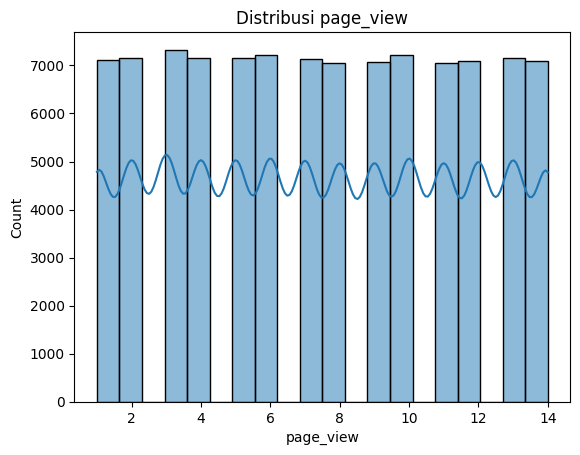

In [14]:
#mengecek distribusi Page view
sns.histplot(df_clean['page_view'], bins = 20, kde=True)
plt.title('Distribusi page_view')

mean = df_clean['page_view'].mean()
std = df_clean['page_view'].std()
x = np.linspace(df_clean['page_view'].min(), df_clean['page_view'].max(), 100)
pdf = stats.norm.pdf(x, mean, std)
plt.show()

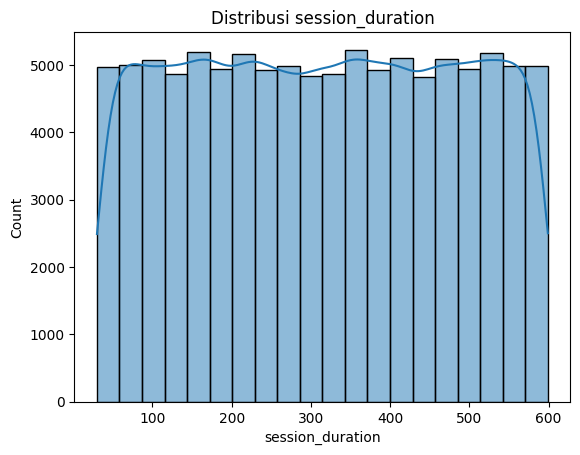

In [15]:
#Mengecek distribusi session_duration
sns.histplot(df_clean['session_duration'], bins = 20, kde=True)
plt.title('Distribusi session_duration')

mean = df_clean['session_duration'].mean()
std = df_clean['session_duration'].std()
x = np.linspace(df_clean['session_duration'].min(), df_clean['session_duration'].max(), 100)
pdf = stats.norm.pdf(x, mean, std)
plt.show()

In [16]:
df_clean['date'] = pd.to_datetime(df_clean['date'], format='%Y-%m-%d')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           100000 non-null  int64         
 1   variant           100000 non-null  object        
 2   date              100000 non-null  datetime64[ns]
 3   device            100000 non-null  object        
 4   browser           100000 non-null  object        
 5   country           100000 non-null  object        
 6   page_view         100000 non-null  int64         
 7   click             100000 non-null  int64         
 8   add_to_cart       100000 non-null  int64         
 9   purchase          100000 non-null  int64         
 10  revenue           100000 non-null  int64         
 11  session_duration  100000 non-null  int64         
 12  impressions       100000 non-null  int64         
 13  traffic_source    100000 non-null  object        
 14  gende

<Axes: >

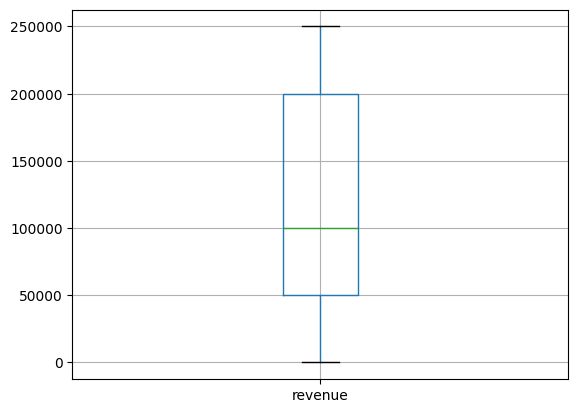

In [17]:
df_clean.boxplot(column='revenue')

In [20]:
Q1 = df_clean['revenue'].quantile(0.25)
Q3 = df_clean['revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_revenue = (
    (df_clean['revenue'] < lower_bound) |
    (df_clean['revenue'] > upper_bound)
)

jumlah_outlier = outlier_revenue.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier revenue: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier revenue: 0
Total data: 100000
Persentase outlier: 0.00%


<Axes: >

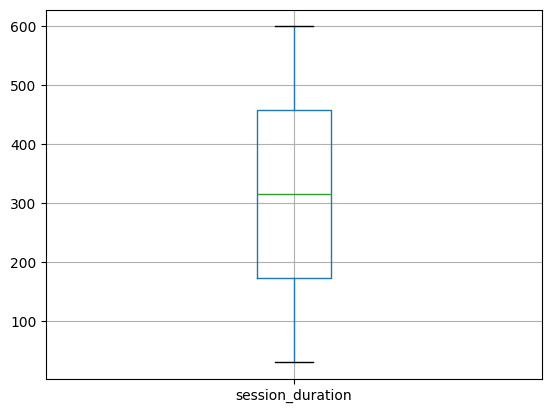

In [18]:
df_clean.boxplot(column='session_duration')

In [21]:
Q1 = df_clean['session_duration'].quantile(0.25)
Q3 = df_clean['session_duration'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_session_duration = (
    (df_clean['session_duration'] < lower_bound) |
    (df_clean['session_duration'] > upper_bound)
)

jumlah_outlier = outlier_session_duration.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier session_duration: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier session_duration: 0
Total data: 100000
Persentase outlier: 0.00%


<Axes: >

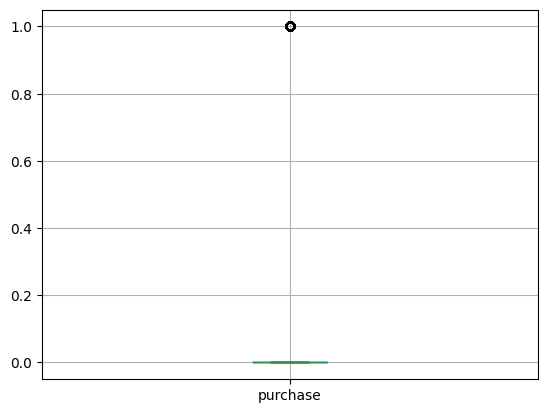

In [19]:
df_clean.boxplot(column='purchase')

In [22]:
Q1 = df_clean['purchase'].quantile(0.25)
Q3 = df_clean['purchase'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_purchase = (
    (df_clean['purchase'] < lower_bound) |
    (df_clean['purchase'] > upper_bound)
)

jumlah_outlier = outlier_purchase.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier purchase: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier purchase: 7061
Total data: 100000
Persentase outlier: 7.06%


In [23]:
df_clean.head()

,user_id,variant,date,device,browser,country,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,traffic_source,gender,age
0,1,A,2025-01-09,Mobile,Chrome,TH,10,0,0,0,100000,122,1,TikTok Ads,M,20
1,2,B,2025-01-04,Tablet,Edge,ID,6,1,0,0,50000,325,24,Organic,F,21
2,3,A,2025-01-06,Mobile,Firefox,MY,4,0,0,0,200000,446,25,Google Ads,F,38
3,4,A,2025-01-24,Tablet,Safari,TH,2,1,1,0,50000,441,11,Organic,F,42
4,5,A,2025-01-26,Desktop,Edge,ID,5,0,0,0,100000,188,26,TikTok Ads,F,40


In [ ]:
#melakukan inkosistensi data dengan mengubah semua string menjadi huruf kecil dan menghapus spasi di awal dan akhir
df_clean['variant'] = df_clean['variant'].str.strip().str.lower()
df_clean['device'] = df_clean['device'].str.strip().str.lower()
df_clean['browser'] = df_clean['browser'].str.strip().str.lower()
df_clean['country'] = df_clean['country'].str.strip().str.lower()
df_clean['traffic_source'] = df_clean['traffic_source'].str.strip().str.lower()
df_clean['gender'] = df_clean['gender'].str.strip().str.lower()
df_clean.head()

,user_id,variant,date,device,browser,country,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,traffic_source,gender,age
0,1,a,2025-01-09,mobile,chrome,th,10,0,0,0,100000,122,1,tiktok ads,m,20
1,2,b,2025-01-04,tablet,edge,id,6,1,0,0,50000,325,24,organic,f,21
2,3,a,2025-01-06,mobile,firefox,my,4,0,0,0,200000,446,25,google ads,f,38
3,4,a,2025-01-24,tablet,safari,th,2,1,1,0,50000,441,11,organic,f,42
4,5,a,2025-01-26,desktop,edge,id,5,0,0,0,100000,188,26,tiktok ads,f,40


mengidentifikasi data normal atau tidak dengan category browser dan numeriknya page_view

In [26]:
#mengidentifikasi data normal atau tidak menggunakan saphiiro wilk
for x in df_clean['browser'].unique():
    stat, p = shapiro(df_clean[df_clean['browser'] == x]['page_view'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

chrome p-value: 8.359280771687571e-69
chrome data tidak normal
edge p-value: 7.880090450288544e-69
edge data tidak normal
firefox p-value: 4.30303371469813e-69
firefox data tidak normal
safari p-value: 7.197408043817108e-69
safari data tidak normal


c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24981.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25134.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25096.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24789.
  res =

mengidentifikasi data normal atau tidak dengan category traffic_source dan numeriknya page_view

In [27]:
for x in df_clean['traffic_source'].unique():
    stat, p = shapiro(df_clean[df_clean['traffic_source'] == x]['page_view'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

tiktok ads p-value: 1.2752280960827702e-68
tiktok ads data tidak normal
organic p-value: 5.95154656189652e-69
organic data tidak normal
google ads p-value: 1.2226238770946206e-69
google ads data tidak normal
instagram p-value: 2.188371782048926e-68
instagram data tidak normal


c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24925.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25268.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25068.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24739.
  res =

mengidentifikasi data normal atau tidak dengan category device dan numeriknya page_view

In [28]:
for x in df_clean['device'].unique():
    stat, p = shapiro(df_clean[df_clean['device'] == x]['page_view'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

mobile p-value: 1.5536797680414044e-74
mobile data tidak normal
tablet p-value: 1.4028363452983408e-74
tablet data tidak normal
desktop p-value: 8.749435431742864e-75
desktop data tidak normal


c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33315.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33078.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33607.
  res = hypotest_fun_out(*samples, **kwds)


mengidentifikasi data normal atau tidak dengan category browser dan numeriknya revenue

In [30]:
#mengidentifikasi data normal atau tidak menggunakan saphiiro wilk
for x in df_clean['browser'].unique():
    stat, p = shapiro(df_clean[df_clean['browser'] == x]['revenue'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

chrome p-value: 7.426343772877502e-80
chrome data tidak normal
edge p-value: 3.3608698208460047e-80
edge data tidak normal
firefox p-value: 2.0071175975220982e-80
firefox data tidak normal
safari p-value: 4.263172125152092e-80
safari data tidak normal


c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24981.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25134.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25096.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24789.
  res =

mengidentifikasi data normal atau tidak dengan category traffic_source dan numeriknya revenue

In [31]:
for x in df_clean['traffic_source'].unique():
    stat, p = shapiro(df_clean[df_clean['traffic_source'] == x]['revenue'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

tiktok ads p-value: 7.426512239905388e-80
tiktok ads data tidak normal
organic p-value: 1.9682356100757007e-80
organic data tidak normal
google ads p-value: 2.83595814392491e-80
google ads data tidak normal
instagram p-value: 5.1123828042113426e-80
instagram data tidak normal


c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24925.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25268.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25068.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24739.
  res =

mengidentifikasi data normal atau tidak dengan category device dan numeriknya revenue

In [32]:
for x in df_clean['device'].unique():
    stat, p = shapiro(df_clean[df_clean['device'] == x]['revenue'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

mobile p-value: 1.3254941281732913e-86
mobile data tidak normal
tablet p-value: 2.536810582103244e-86
tablet data tidak normal
desktop p-value: 2.8305956070949982e-86
desktop data tidak normal


c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33315.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33078.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33607.
  res = hypotest_fun_out(*samples, **kwds)


mengidentifikasi data normal atau tidak dengan category browser, traffic_source, device dan numeriknya session_duration

In [33]:
#mengidentifikasi data normal atau tidak menggunakan saphiiro wilk
for x in df_clean['browser'].unique():
    stat, p = shapiro(df_clean[df_clean['browser'] == x]['session_duration'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

chrome p-value: 1.5615362457501844e-64
chrome data tidak normal
edge p-value: 1.6373206483011697e-64
edge data tidak normal
firefox p-value: 1.0296845520795625e-64
firefox data tidak normal
safari p-value: 6.274023366398417e-65
safari data tidak normal


In [34]:
for x in df_clean['traffic_source'].unique():
    stat, p = shapiro(df_clean[df_clean['traffic_source'] == x]['session_duration'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

tiktok ads p-value: 1.5438754633730748e-64
tiktok ads data tidak normal
organic p-value: 3.7337885917043796e-65
organic data tidak normal
google ads p-value: 2.047021345976937e-64
google ads data tidak normal
instagram p-value: 1.4094574285930338e-64
instagram data tidak normal


In [35]:
for x in df_clean['device'].unique():
    stat, p = shapiro(df_clean[df_clean['device'] == x]['session_duration'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

mobile p-value: 3.0210698931645986e-70
mobile data tidak normal
tablet p-value: 1.1361443110150375e-69
tablet data tidak normal
desktop p-value: 1.1502919019652559e-70
desktop data tidak normal


mengidentifikasi data normal atau tidak dengan category browser, traffic_source, device dan numeriknya impression

In [36]:
#mengidentifikasi data normal atau tidak menggunakan saphiiro wilk
for x in df_clean['browser'].unique():
    stat, p = shapiro(df_clean[df_clean['browser'] == x]['impressions'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

chrome p-value: 1.2857662940624544e-65
chrome data tidak normal
edge p-value: 1.0601716594232666e-65
edge data tidak normal
firefox p-value: 7.351512764182359e-66
firefox data tidak normal
safari p-value: 2.020370777664029e-65
safari data tidak normal


In [ ]:
for x in df_clean['traffic_source'].unique():
    stat, p = shapiro(df_clean[df_clean['traffic_source'] == x]['impressions'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

tiktok ads p-value: 7.603932297309425e-66
tiktok ads data tidak normal
organic p-value: 1.6097334088395762e-65
organic data tidak normal
google ads p-value: 4.971827826626449e-66
google ads data tidak normal
instagram p-value: 3.431659289213761e-65
instagram data tidak normal


In [38]:
for x in df_clean['device'].unique():
    stat, p = shapiro(df_clean[df_clean['device'] == x]['impressions'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

mobile p-value: 3.683313318452549e-71
mobile data tidak normal
tablet p-value: 2.8151398219498924e-71
tablet data tidak normal
desktop p-value: 3.1472511481648087e-71
desktop data tidak normal


In [39]:
df_clean.to_csv('ab_testing_dataset_100k_clean.csv', index=False)